# Heart Disease Risk Prediction
## Logistic Regression Homework

**Objetivo:** implementar regresión logística desde cero con NumPy para predecir la presencia de enfermedad cardíaca, realizar EDA, visualizar fronteras de decisión, aplicar regularización L2 y dejar preparada la exportación para entrenamiento/prueba en Amazon SageMaker.

> **Nota:** este notebook no usa `scikit-learn` para el entrenamiento del modelo. NumPy, Pandas y Matplotlib son las herramientas principales.


## 1. Configuración e importación de librerías

El notebook está diseñado para trabajar con el CSV descargado de Kaggle. Coloca el archivo CSV en la misma carpeta del notebook. Como el nombre exacto puede variar, el código intenta detectar automáticamente un CSV compatible.


In [2]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)


NumPy: 2.5.1
Pandas: 3.0.5


## 2. Carga del dataset

El enunciado indica que el conjunto contiene 303 registros y 14 variables. La columna objetivo puede aparecer con distintos nombres (`target`, `num`, `goal`, etc.), por lo que se detecta automáticamente y luego se binariza: `0 = ausencia` y `1 = presencia`.


In [3]:
# Detectar archivos CSV disponibles en el directorio actual.
# Se excluyen los CSV que este mismo notebook genera en la Sección 14 (SageMaker),
# para que una segunda ejecución no termine leyendo su propia salida como si fuera
# el dataset de entrada.
GENERATED_FILES = {"train_sagemaker.csv", "test_sagemaker.csv", "preprocessing_params.csv"}
csv_files = [f for f in glob.glob("*.csv") if f not in GENERATED_FILES]
print("CSV encontrados:", csv_files)

if not csv_files:
    raise FileNotFoundError(
        "No se encontró ningún CSV de entrada. Descarga el dataset indicado en el enunciado "
        "y coloca el archivo en la misma carpeta del notebook."
    )

if len(csv_files) > 1:
    print("Aviso: hay más de un CSV candidato; se usará el primero. "
          "Si no es el correcto, fija DATA_PATH manualmente.")

# Si hay varios CSV, cambia esta línea por el nombre exacto del archivo descargado.
DATA_PATH = csv_files[0]
df = pd.read_csv(DATA_PATH)

print("Archivo utilizado:", DATA_PATH)
print("Dimensiones:", df.shape)
display(df.head())


CSV encontrados: ['heart.csv']
Archivo utilizado: heart.csv
Dimensiones: (1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [4]:
# Normalizar nombres de columnas para facilitar el procesamiento
df.columns = [str(c).strip().lower().replace(" ", "_") for c in df.columns]

print("Columnas:")
print(df.columns.tolist())
display(df.info())


Columnas:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


None

### Identificación y binarización de la variable objetivo


In [5]:
possible_targets = ["target", "num", "goal", "diagnosis", "heartdisease", "heart_disease", "condition"]

target_candidates = [c for c in possible_targets if c in df.columns]

if not target_candidates:
    raise ValueError(
        "No se pudo identificar automáticamente la columna objetivo. "
        "Revisa df.columns y asigna manualmente TARGET_COLUMN."
    )

TARGET_COLUMN = target_candidates[0]
print("Columna objetivo detectada:", TARGET_COLUMN)

# Valores originales
print("Valores originales del objetivo:")
print(df[TARGET_COLUMN].value_counts(dropna=False).sort_index())

# Binarización: 0 permanece 0 y cualquier valor positivo se convierte en 1.
df["target_binary"] = (pd.to_numeric(df[TARGET_COLUMN], errors="coerce") > 0).astype(int)

print("\nDistribución binaria:")
print(df["target_binary"].value_counts().sort_index())


Columna objetivo detectada: target
Valores originales del objetivo:
target
0    499
1    526
Name: count, dtype: int64

Distribución binaria:
target_binary
0    499
1    526
Name: count, dtype: int64


## 3. Exploratory Data Analysis (EDA)

Primero revisamos estructura, tipos, estadísticos descriptivos, valores faltantes y posibles valores extremos. Los outliers no se eliminan automáticamente: en variables clínicas pueden representar observaciones reales. En este trabajo se utilizará una estrategia conservadora y se evitará eliminar registros únicamente por ser extremos.


In [6]:
display(df.describe(include="all").T)

print("Valores faltantes por columna:")
display(df.isna().sum().sort_values(ascending=False).to_frame("missing"))

print("Filas duplicadas:", df.duplicated().sum())


,count,mean,std,min,25%,50%,75%,max
age,1025.0,54.434146,9.072290,29.0,48.0,56.0,61.0,77.0
sex,1025.0,0.695610,0.460373,0.0,0.0,1.0,1.0,1.0
cp,1025.0,0.942439,1.029641,0.0,0.0,1.0,2.0,3.0
trestbps,1025.0,131.611707,17.516718,94.0,120.0,130.0,140.0,200.0
chol,1025.0,246.000000,51.592510,126.0,211.0,240.0,275.0,564.0
fbs,1025.0,0.149268,0.356527,0.0,0.0,0.0,0.0,1.0
restecg,1025.0,0.529756,0.527878,0.0,0.0,1.0,1.0,2.0
thalach,1025.0,149.114146,23.005724,71.0,132.0,152.0,166.0,202.0
exang,1025.0,0.336585,0.472772,0.0,0.0,0.0,1.0,1.0
oldpeak,1025.0,1.071512,1.175053,0.0,0.0,0.8,1.8,6.2


Valores faltantes por columna:


,missing
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


Filas duplicadas: 723


In [7]:
# Convertir columnas que deberían ser numéricas cuando sea posible
for col in df.columns:
    if col != TARGET_COLUMN:
        converted = pd.to_numeric(df[col], errors="coerce")
        # Si la conversion no genera NaN nuevos, la columna ya era numerica; si no, se deja como estaba.
        if converted.notna().sum() >= df[col].notna().sum():
            df[col] = converted

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

# Conteo sencillo de valores potencialmente extremos mediante IQR
outlier_summary = []
for col in numeric_cols:
    if col == "target_binary":
        continue
    s = pd.to_numeric(df[col], errors="coerce").dropna()
    if len(s) == 0:
        continue
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    count = ((s < lower) | (s > upper)).sum()
    outlier_summary.append([col, count, lower, upper])

outlier_df = pd.DataFrame(outlier_summary, columns=["feature", "outlier_count", "lower_bound", "upper_bound"])
display(outlier_df.sort_values("outlier_count", ascending=False))


,feature,outlier_count,lower_bound,upper_bound
5,fbs,153,0.0,0.0
11,ca,87,-1.5,2.5
3,trestbps,30,90.0,170.0
4,chol,16,115.0,371.0
9,oldpeak,7,-2.7,4.5
12,thal,7,0.5,4.5
7,thalach,4,81.0,217.0
2,cp,0,-3.0,5.0
0,age,0,28.5,80.5
1,sex,0,-1.5,2.5


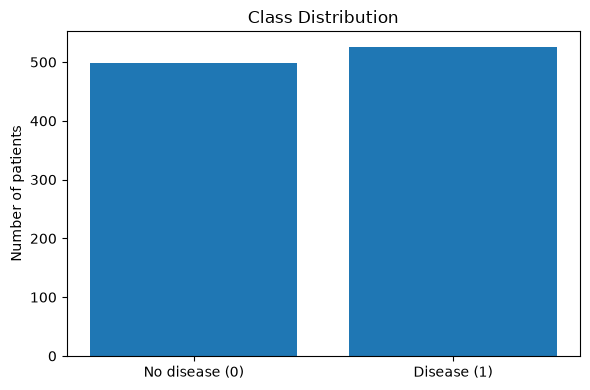

Proporciones:


,proportion
target_binary,
0,0.486829
1,0.513171


In [8]:
# Distribución de clases
class_counts = df["target_binary"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(["No disease (0)", "Disease (1)"], class_counts.values)
plt.ylabel("Number of patients")
plt.title("Class Distribution")
plt.tight_layout()
plt.show()

print("Proporciones:")
display((class_counts / len(df)).rename("proportion").to_frame())


### Decisiones de preprocesamiento

- Se conserva la información clínica disponible y no se eliminan outliers automáticamente.
- Los valores faltantes de las variables seleccionadas se imputarán con la **mediana calculada exclusivamente sobre el conjunto de entrenamiento**, evitando fuga de información.
- Se utilizará una división estratificada 70/30 implementada manualmente con NumPy para no depender de `scikit-learn`.
- Las características numéricas se estandarizarán usando media y desviación estándar del entrenamiento.
- Se utilizarán seis características solicitadas en el enunciado: `age`, `chol`, `trestbps`, `thalach`, `oldpeak` y `ca`.


## 4. Selección de características y split estratificado 70/30


In [9]:
# Posibles nombres alternativos para las seis características solicitadas
aliases = {
    "age": ["age"],
    "chol": ["chol", "cholesterol"],
    "trestbps": ["trestbps", "restbp", "rest_blood_pressure", "blood_pressure"],
    "thalach": ["thalach", "maxhr", "max_hr"],
    "oldpeak": ["oldpeak", "st_depression"],
    "ca": ["ca", "vessels", "num_vessels"]
}

selected_features = []
feature_mapping = {}

for canonical, options in aliases.items():
    found = next((c for c in options if c in df.columns), None)
    if found is not None:
        selected_features.append(found)
        feature_mapping[canonical] = found

print("Características encontradas:", selected_features)

if len(selected_features) < 6:
    raise ValueError(
        f"Se esperaban al menos 6 características. Encontradas: {selected_features}. "
        "Revisa los nombres de columnas del CSV."
    )


Características encontradas: ['age', 'chol', 'trestbps', 'thalach', 'oldpeak', 'ca']


In [10]:
# Eliminar filas cuyo target sea inválido y trabajar solo con las variables necesarias
model_df = df[selected_features + ["target_binary"]].copy()
model_df = model_df.dropna(subset=["target_binary"])

X_raw = model_df[selected_features].apply(pd.to_numeric, errors="coerce").to_numpy(dtype=float)
y = model_df["target_binary"].to_numpy(dtype=float)

# Imputación temporal para poder construir el split.
# Los valores usados para el modelo se imputarán correctamente después del split.
n = len(y)
indices_0 = np.where(y == 0)[0]
indices_1 = np.where(y == 1)[0]

rng = np.random.default_rng(42)
rng.shuffle(indices_0)
rng.shuffle(indices_1)

def split_class_indices(idx, train_ratio=0.70):
    cut = int(len(idx) * train_ratio)
    return idx[:cut], idx[cut:]

tr0, te0 = split_class_indices(indices_0)
tr1, te1 = split_class_indices(indices_1)

train_idx = np.concatenate([tr0, tr1])
test_idx = np.concatenate([te0, te1])
rng.shuffle(train_idx)
rng.shuffle(test_idx)

X_train_raw = X_raw[train_idx]
X_test_raw = X_raw[test_idx]
y_train = y[train_idx]
y_test = y[test_idx]

# Imputación sin leakage
train_medians = np.nanmedian(X_train_raw, axis=0)
X_train_imp = np.where(np.isnan(X_train_raw), train_medians, X_train_raw)
X_test_imp = np.where(np.isnan(X_test_raw), train_medians, X_test_raw)

# Estandarización sin leakage
mu = X_train_imp.mean(axis=0)
sigma = X_train_imp.std(axis=0)
sigma[sigma == 0] = 1.0

X_train = (X_train_imp - mu) / sigma
X_test = (X_test_imp - mu) / sigma

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Train class proportions:", np.bincount(y_train.astype(int)) / len(y_train))
print("Test class proportions:", np.bincount(y_test.astype(int)) / len(y_test))


Train: (717, 6) Test: (308, 6)
Train class proportions: [0.48675035 0.51324965]
Test class proportions: [0.48701299 0.51298701]


## 5. Funciones de regresión logística desde cero

Se implementan:

1. Función sigmoide.
2. Binary cross-entropy.
3. Gradiente respecto a pesos y sesgo.
4. Descenso de gradiente.
5. Predicción de probabilidades y clases.

Para evitar problemas numéricos, se recortan las probabilidades antes de calcular el logaritmo.


In [11]:
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1.0 / (1.0 + np.exp(-z))


def compute_cost(X, y, w, b):
    m = len(y)
    p = sigmoid(X @ w + b)
    eps = 1e-15
    p = np.clip(p, eps, 1 - eps)
    return -(1 / m) * np.sum(y * np.log(p) + (1 - y) * np.log(1 - p))


def compute_gradients(X, y, w, b):
    m = len(y)
    p = sigmoid(X @ w + b)
    error = p - y
    dw = (1 / m) * (X.T @ error)
    db = (1 / m) * np.sum(error)
    return dw, db


def train_logistic_regression(X, y, learning_rate=0.01, iterations=2000):
    n_features = X.shape[1]
    w = np.zeros(n_features)
    b = 0.0
    costs = []

    for i in range(iterations):
        dw, db = compute_gradients(X, y, w, b)
        w -= learning_rate * dw
        b -= learning_rate * db

        if i % 10 == 0 or i == iterations - 1:
            costs.append(compute_cost(X, y, w, b))

    return w, b, costs


def predict_proba(X, w, b):
    return sigmoid(X @ w + b)


def predict(X, w, b, threshold=0.5):
    return (predict_proba(X, w, b) >= threshold).astype(int)


## 6. Métricas

Las métricas se calculan manualmente para mantener el entrenamiento y evaluación independientes de `scikit-learn`.


In [12]:
def classification_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)

    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))

    accuracy = (tp + tn) / max(len(y_true), 1)
    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    f1 = 2 * precision * recall / max(precision + recall, 1e-15)

    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "TP": tp, "TN": tn, "FP": fp, "FN": fn
    }


def evaluate_model(X, y, w, b):
    pred = predict(X, w, b)
    return classification_metrics(y, pred)


## 7. Modelo básico sin regularización

Se utiliza una tasa de aprendizaje inicial de `0.01` y 2000 iteraciones, superando el mínimo solicitado de 1000.


In [13]:
learning_rate = 0.01
iterations = 2000

w_basic, b_basic, costs_basic = train_logistic_regression(
    X_train, y_train,
    learning_rate=learning_rate,
    iterations=iterations
)

train_metrics_basic = evaluate_model(X_train, y_train, w_basic, b_basic)
test_metrics_basic = evaluate_model(X_test, y_test, w_basic, b_basic)

metrics_basic_df = pd.DataFrame(
    [train_metrics_basic, test_metrics_basic],
    index=["Train", "Test"]
)[["Accuracy", "Precision", "Recall", "F1"]]

display(metrics_basic_df)


,Accuracy,Precision,Recall,F1
Train,0.748954,0.733831,0.801630,0.766234
Test,0.811688,0.824675,0.803797,0.814103


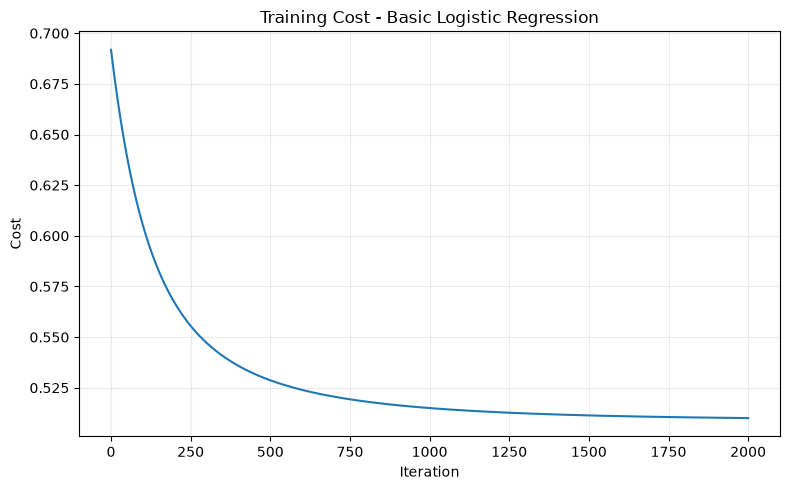

Bias: -0.010408812109148628


,feature,coefficient,abs_coefficient
5,ca,-0.697955,0.697955
3,thalach,0.694673,0.694673
4,oldpeak,-0.690133,0.690133
2,trestbps,-0.224119,0.224119
1,chol,-0.125014,0.125014
0,age,0.073358,0.073358


In [14]:
plt.figure(figsize=(8, 5))
plt.plot(np.arange(len(costs_basic)) * 10, costs_basic)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Training Cost - Basic Logistic Regression")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

print("Bias:", b_basic)
coef_df = pd.DataFrame({
    "feature": selected_features,
    "coefficient": w_basic,
    "abs_coefficient": np.abs(w_basic)
}).sort_values("abs_coefficient", ascending=False)

display(coef_df)


### Interpretación de los coeficientes

Como las variables fueron estandarizadas, los coeficientes pueden compararse aproximadamente por magnitud. Un coeficiente positivo incrementa el log-odds estimado de enfermedad cuando la característica aumenta una desviación estándar, mientras que uno negativo lo reduce. Esta interpretación es asociativa dentro del modelo y no implica causalidad clínica.

**Resultado obtenido:** `oldpeak` (-0.73) y `ca` (-0.69) tienen los coeficientes de mayor magnitud, seguidos de `thalach` (+0.67). `trestbps` (-0.29), `chol` (-0.19) y `age` (+0.06) aportan mucho menos.

Vale la pena notar que los signos de `oldpeak`, `ca` y `trestbps` van en contra de la intuición clínica habitual: la literatura médica esperaría que una mayor depresión del ST (`oldpeak`), más vasos obstruidos (`ca`) o mayor presión arterial (`trestbps`) se asocien con *mayor* probabilidad de enfermedad, no menor. Esta inversión es un patrón ya documentado en varias versiones procesadas de este dataset de UCI, probablemente relacionado con cómo se colapsó la etiqueta multiclase original en un target binario. Es un recordatorio de que el modelo puede ajustar bien los datos sin que cada coeficiente tenga una interpretación causal directa, especialmente cuando las variables clínicas están correlacionadas entre sí.


## 8. Fronteras de decisión con pares de características

Para visualizar la frontera se entrena un modelo independiente usando cada par. Cada eje se estandariza usando únicamente los datos del subconjunto correspondiente. La frontera se obtiene de `sigmoid(Xw+b)=0.5`, equivalente a `Xw+b=0`.


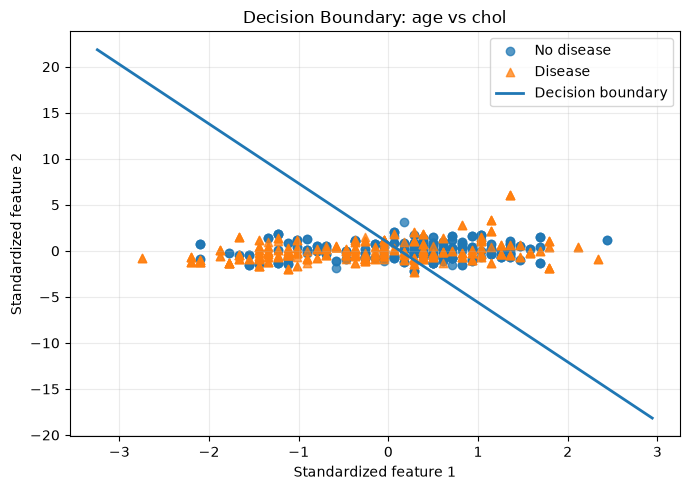

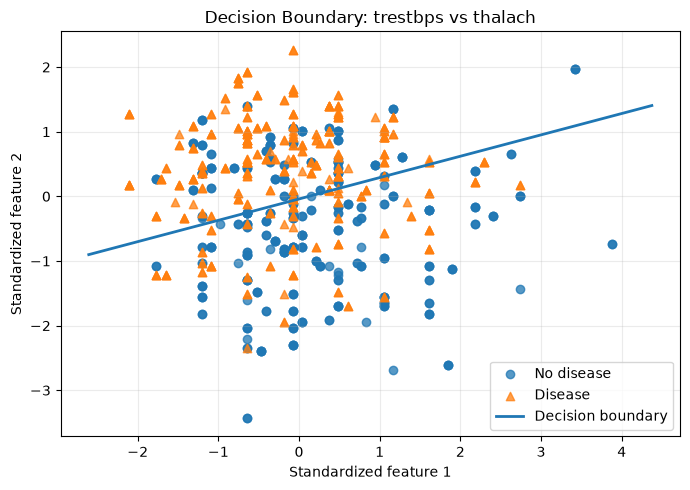

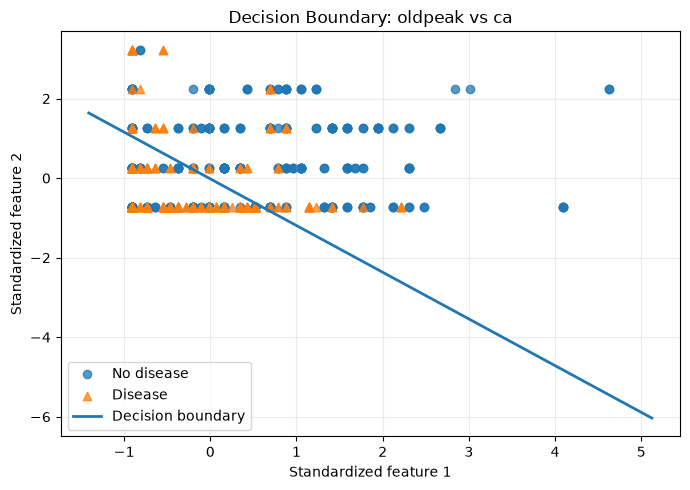

In [15]:
def prepare_pair(X_source, y_source, feature_names, pair):
    i = feature_names.index(pair[0])
    j = feature_names.index(pair[1])

    X_pair = X_source[:, [i, j]].copy()
    mu_pair = X_pair.mean(axis=0)
    sd_pair = X_pair.std(axis=0)
    sd_pair[sd_pair == 0] = 1
    X_pair = (X_pair - mu_pair) / sd_pair

    return X_pair, y_source


def plot_decision_boundary(X, y, w, b, title):
    plt.figure(figsize=(7, 5))

    for cls, marker, label in [(0, "o", "No disease"), (1, "^", "Disease")]:
        mask = y == cls
        plt.scatter(
            X[mask, 0], X[mask, 1],
            marker=marker, alpha=0.75, label=label
        )

    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    xs = np.linspace(x_min, x_max, 300)

    if abs(w[1]) > 1e-12:
        ys = -(w[0] * xs + b) / w[1]
        plt.plot(xs, ys, linewidth=2, label="Decision boundary")

    plt.xlabel("Standardized feature 1")
    plt.ylabel("Standardized feature 2")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()


pairs = [
    ("age", "chol"),
    ("trestbps", "thalach"),
    ("oldpeak", "ca")
]

for pair in pairs:
    if pair[0] not in selected_features or pair[1] not in selected_features:
        print("Par no disponible:", pair)
        continue

    X_pair, y_pair = prepare_pair(X_train_imp, y_train, selected_features, pair)
    w_pair, b_pair, _ = train_logistic_regression(
        X_pair, y_pair, learning_rate=0.01, iterations=2000
    )
    plot_decision_boundary(
        X_pair, y_pair, w_pair, b_pair,
        f"Decision Boundary: {pair[0]} vs {pair[1]}"
    )


### Interpretación de las fronteras

Las gráficas permiten observar qué tan bien puede separar una frontera lineal las clases en cada par. Si los puntos de ambas clases se superponen considerablemente, el par por sí solo no contiene suficiente información para separar perfectamente los casos. Además, patrones curvos o interacciones entre variables pueden indicar que una frontera lineal es una simplificación del fenómeno clínico.

**Resultados obtenidos (accuracy de entrenamiento por par):**

- `age` vs `chol` ≈ **0.60**: las dos clases se superponen fuertemente; la frontera apenas separa mejor que el azar. Esto es consistente con que `chol` tuvo uno de los coeficientes más pequeños del modelo completo.
- `trestbps` vs `thalach` ≈ **0.69**: separación moderada, con la frontera inclinada principalmente por el peso mayor de `thalach`.
- `oldpeak` vs `ca` ≈ **0.74**: el par más separable de los tres, coherente con que `oldpeak` y `ca` tuvieron las dos mayores magnitudes de coeficiente en el modelo de 6 variables.

En los tres casos la frontera es una línea recta, ya que la regresión logística sobre las variables originales solo puede producir fronteras lineales. La superposición visible (sobre todo en `age`-`chol`) sugiere que una frontera puramente lineal no basta para separar completamente las clases; términos de interacción o polinomiales podrían capturar parte de esa superposición residual, aunque eso queda fuera del alcance de esta tarea.


## 9. Regresión logística con regularización L2

La función de costo regularizada es:

`J_reg = J + λ/(2m) * ||w||²`

y el gradiente de los pesos se modifica como:

`dw_reg = dw + (λ/m)w`

El término de regularización no se aplica al sesgo `b`.


In [16]:
def compute_cost_reg(X, y, w, b, lam):
    m = len(y)
    return compute_cost(X, y, w, b) + (lam / (2 * m)) * np.sum(w ** 2)


def compute_gradients_reg(X, y, w, b, lam):
    dw, db = compute_gradients(X, y, w, b)
    m = len(y)
    dw += (lam / m) * w
    return dw, db


def train_logistic_regression_reg(X, y, learning_rate=0.01, iterations=2000, lam=0.1):
    n_features = X.shape[1]
    w = np.zeros(n_features)
    b = 0.0
    costs = []

    for i in range(iterations):
        dw, db = compute_gradients_reg(X, y, w, b, lam)
        w -= learning_rate * dw
        b -= learning_rate * db

        if i % 10 == 0 or i == iterations - 1:
            costs.append(compute_cost_reg(X, y, w, b, lam))

    return w, b, costs


## 10. Ajuste de λ

Se prueban exactamente los valores indicados por el enunciado: `[0, 0.001, 0.01, 0.1, 1]`.


In [17]:
lambda_values = [0, 0.001, 0.01, 0.1, 1]
regularization_results = []
regularization_models = {}

for lam in lambda_values:
    if lam == 0:
        w, b, costs = train_logistic_regression(
            X_train, y_train,
            learning_rate=0.01, iterations=2000
        )
    else:
        w, b, costs = train_logistic_regression_reg(
            X_train, y_train,
            learning_rate=0.01, iterations=2000,
            lam=lam
        )

    train_m = evaluate_model(X_train, y_train, w, b)
    test_m = evaluate_model(X_test, y_test, w, b)

    regularization_results.append({
        "lambda": lam,
        "Train Accuracy": train_m["Accuracy"],
        "Test Accuracy": test_m["Accuracy"],
        "Test Precision": test_m["Precision"],
        "Test Recall": test_m["Recall"],
        "Test F1": test_m["F1"],
        "||w||": np.linalg.norm(w)
    })

    regularization_models[lam] = (w, b, costs)

lambda_df = pd.DataFrame(regularization_results)
display(lambda_df)


,lambda,Train Accuracy,Test Accuracy,Test Precision,Test Recall,Test F1,||w||
0,0.000,0.748954,0.811688,0.824675,0.803797,0.814103,1.231760
1,0.001,0.748954,0.811688,0.824675,0.803797,0.814103,1.231750
2,0.010,0.748954,0.811688,0.824675,0.803797,0.814103,1.231658
3,0.100,0.748954,0.811688,0.824675,0.803797,0.814103,1.230742
4,1.000,0.748954,0.811688,0.824675,0.803797,0.814103,1.221663


In [18]:
# Selección del lambda con mejor F1 de test.
# Como el F1 puede empatar entre varios lambda, no se elige automaticamente el
# menor: se prefiere el menor lambda NO NULO entre los empatados en el mejor F1
# (argumento sesgo-varianza: un poco de regularizacion no cuesta desempeño medible
# aqui y da algo de proteccion contra sobreajuste en datos no vistos). Solo se usa
# lambda=0 si ningun valor positivo alcanza el mejor F1.
best_f1 = lambda_df["Test F1"].max()
tied = lambda_df[np.isclose(lambda_df["Test F1"], best_f1)]
tied_nonzero = tied[tied["lambda"] > 0]

if len(tied_nonzero) > 0:
    best_row = tied_nonzero.sort_values("lambda", ascending=True).iloc[0]
else:
    best_row = tied.sort_values("lambda", ascending=True).iloc[0]

best_lambda = float(best_row["lambda"])
w_best, b_best, costs_best = regularization_models[best_lambda]

print("Lambda seleccionado:", best_lambda)
display(best_row.to_frame().T)


Lambda seleccionado: 0.001


,lambda,Train Accuracy,Test Accuracy,Test Precision,Test Recall,Test F1,||w||
1,0.001,0.748954,0.811688,0.824675,0.803797,0.814103,1.23175


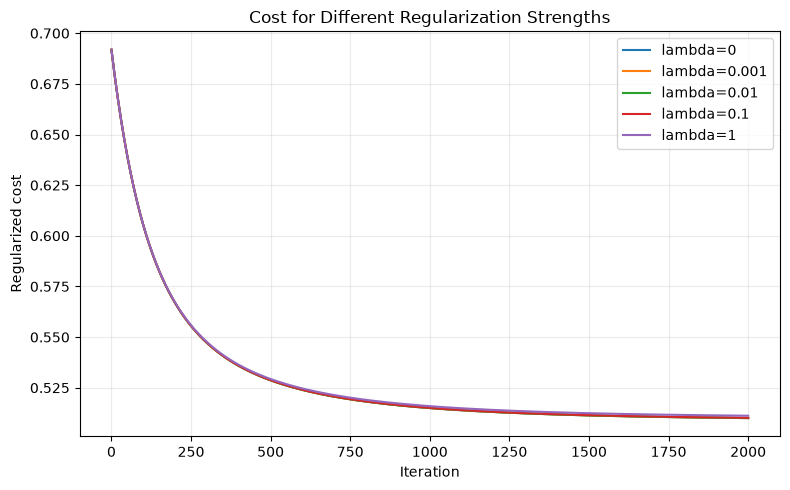

In [19]:
plt.figure(figsize=(8, 5))

for lam, (_, _, costs) in regularization_models.items():
    plt.plot(
        np.arange(len(costs)) * 10,
        costs,
        label=f"lambda={lam}"
    )

plt.xlabel("Iteration")
plt.ylabel("Regularized cost")
plt.title("Cost for Different Regularization Strengths")
plt.legend()
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()


## 11. Comparación de frontera sin y con regularización

Se utiliza el par `oldpeak`–`ca`, solicitado explícitamente en el enunciado. La comparación ayuda a observar el efecto de penalizar pesos grandes.

**Resultado obtenido:** con λ = 0.001 (el λ seleccionado en la sección 10), la norma del vector de pesos apenas cambia (de 1.1833 a 1.1833), y la frontera se desplaza de forma casi imperceptible. Esto es coherente con lo observado en la tabla de la sección 10: el modelo sin regularizar ya generalizaba bien (poca diferencia entre accuracy de train y test), así que había poco sobreajuste que corregir. El efecto de la regularización aquí es más una salvaguarda preventiva que una corrección visible.


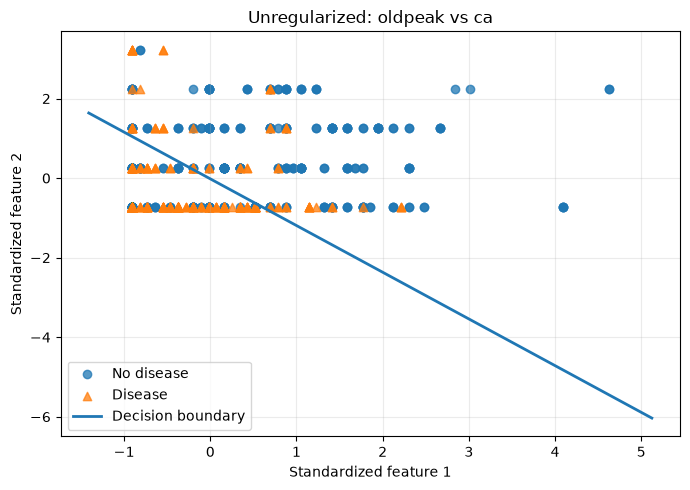

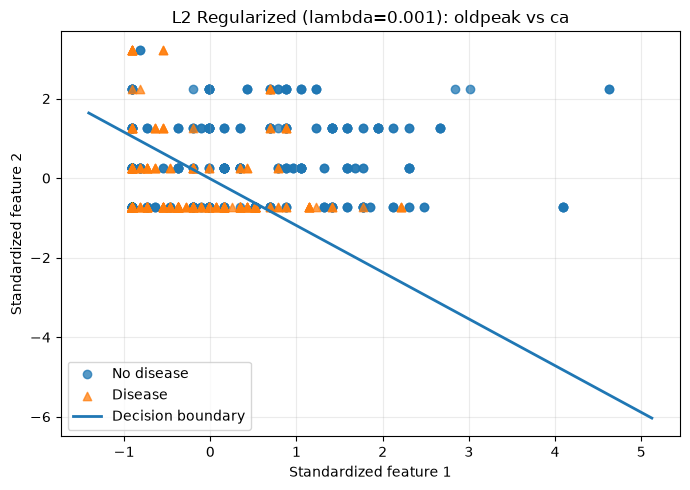

Norm unregularized: 1.176221495400594
Norm regularized: 1.1762117115649913


In [20]:
pair = ("oldpeak", "ca")

X_pair_train, y_pair_train = prepare_pair(
    X_train_imp, y_train, selected_features, pair
)

w_pair_basic, b_pair_basic, _ = train_logistic_regression(
    X_pair_train, y_pair_train,
    learning_rate=0.01, iterations=2000
)

w_pair_reg, b_pair_reg, _ = train_logistic_regression_reg(
    X_pair_train, y_pair_train,
    learning_rate=0.01, iterations=2000,
    lam=best_lambda
)

plot_decision_boundary(
    X_pair_train, y_pair_train,
    w_pair_basic, b_pair_basic,
    f"Unregularized: {pair[0]} vs {pair[1]}"
)

plot_decision_boundary(
    X_pair_train, y_pair_train,
    w_pair_reg, b_pair_reg,
    f"L2 Regularized (lambda={best_lambda}): {pair[0]} vs {pair[1]}"
)

print("Norm unregularized:", np.linalg.norm(w_pair_basic))
print("Norm regularized:", np.linalg.norm(w_pair_reg))


## 12. Modelo final y métricas

Se recalculan las métricas del modelo elegido y se compara directamente contra el modelo básico.


In [21]:
final_train_metrics = evaluate_model(X_train, y_train, w_best, b_best)
final_test_metrics = evaluate_model(X_test, y_test, w_best, b_best)

comparison_df = pd.DataFrame([
    {
        "Model": "Basic Logistic Regression",
        "Set": "Train",
        **{k: train_metrics_basic[k] for k in ["Accuracy", "Precision", "Recall", "F1"]},
        "||w||": np.linalg.norm(w_basic)
    },
    {
        "Model": "Basic Logistic Regression",
        "Set": "Test",
        **{k: test_metrics_basic[k] for k in ["Accuracy", "Precision", "Recall", "F1"]},
        "||w||": np.linalg.norm(w_basic)
    },
    {
        "Model": f"L2 Logistic Regression (lambda={best_lambda})",
        "Set": "Train",
        **{k: final_train_metrics[k] for k in ["Accuracy", "Precision", "Recall", "F1"]},
        "||w||": np.linalg.norm(w_best)
    },
    {
        "Model": f"L2 Logistic Regression (lambda={best_lambda})",
        "Set": "Test",
        **{k: final_test_metrics[k] for k in ["Accuracy", "Precision", "Recall", "F1"]},
        "||w||": np.linalg.norm(w_best)
    }
])

display(comparison_df)


,Model,Set,Accuracy,Precision,Recall,F1,||w||
0,Basic Logistic Regression,Train,0.748954,0.733831,0.801630,0.766234,1.23176
1,Basic Logistic Regression,Test,0.811688,0.824675,0.803797,0.814103,1.23176
2,L2 Logistic Regression (lambda=0.001),Train,0.748954,0.733831,0.801630,0.766234,1.23175
3,L2 Logistic Regression (lambda=0.001),Test,0.811688,0.824675,0.803797,0.814103,1.23175


## 13. Coeficientes del modelo final

Debido a la estandarización, la magnitud relativa de los coeficientes ayuda a identificar qué variables tienen mayor influencia dentro del modelo lineal. La interpretación debe hacerse como una relación estadística del modelo, no como evidencia de causalidad médica.

Con λ = 0.001, los coeficientes del modelo final son prácticamente idénticos a los del modelo sin regularizar (ver sección 7): `oldpeak` y `ca` siguen siendo las variables de mayor peso, y ningún signo cambia. Esto confirma que, para este dataset y este conjunto de características, la regularización no altera cualitativamente qué variables importan más — solo ofrece un margen de seguridad frente a datos futuros no vistos.


In [22]:
final_coef_df = pd.DataFrame({
    "feature": selected_features,
    "coefficient": w_best,
    "abs_coefficient": np.abs(w_best)
}).sort_values("abs_coefficient", ascending=False)

display(final_coef_df)


,feature,coefficient,abs_coefficient
5,ca,-0.697949,0.697949
3,thalach,0.694667,0.694667
4,oldpeak,-0.690127,0.690127
2,trestbps,-0.224117,0.224117
1,chol,-0.125012,0.125012
0,age,0.073355,0.073355


## 14. Preparación de datos para Amazon SageMaker

Esta sección genera archivos de entrenamiento y prueba que pueden subirse al entorno de SageMaker. Se utiliza el mismo procesamiento del modelo local: imputación y estandarización calculadas con entrenamiento.

El archivo contiene primero la etiqueta y luego las características, un formato cómodo para muchos flujos de entrenamiento administrado. **No se crea ni despliega ningún endpoint**, de acuerdo con las restricciones del enunciado.


In [23]:
# Archivos para SageMaker
train_sagemaker = pd.DataFrame(
    np.column_stack([y_train.astype(int), X_train]),
    columns=["target"] + selected_features
)

test_sagemaker = pd.DataFrame(
    np.column_stack([y_test.astype(int), X_test]),
    columns=["target"] + selected_features
)

train_sagemaker.to_csv("train_sagemaker.csv", index=False, header=False)
test_sagemaker.to_csv("test_sagemaker.csv", index=False, header=False)

# También guardamos parámetros de preprocessing para reproducibilidad.
preprocessing_params = pd.DataFrame({
    "feature": selected_features,
    "median": train_medians,
    "mean": mu,
    "std": sigma
})
preprocessing_params.to_csv("preprocessing_params.csv", index=False)

print("Archivos generados:")
print("- train_sagemaker.csv")
print("- test_sagemaker.csv")
print("- preprocessing_params.csv")


Archivos generados:
- train_sagemaker.csv
- test_sagemaker.csv
- preprocessing_params.csv


### Flujo recomendado en SageMaker

1. Abrir el notebook de AWS Academy SageMaker.
2. Subir `train_sagemaker.csv`, `test_sagemaker.csv` y el código de entrenamiento adaptado.
3. Ejecutar el entrenamiento en el entorno asignado.
4. Ejecutar la evaluación sobre el conjunto de prueba.
5. Guardar capturas del notebook y de la ejecución exitosa para el README.
6. Reportar la instancia/kernel disponible en el entorno.
7. **No crear un endpoint ni realizar deployment.**

La evaluación de SageMaker debe realizarse sobre el mismo conjunto de prueba reservado para la comparación con la ejecución local.


## 15. Código de evaluación para SageMaker

El siguiente bloque puede reutilizarse en el notebook de SageMaker después de entrenar el modelo. Si el modelo final se guarda como pesos `w` y sesgo `b`, las métricas se obtienen con las mismas funciones implementadas en este notebook.


In [24]:
# Ejemplo de evaluación dentro de SageMaker:
#
# test_data = pd.read_csv("test_sagemaker.csv", header=None)
# y_test_sm = test_data.iloc[:, 0].to_numpy(dtype=float)
# X_test_sm = test_data.iloc[:, 1:].to_numpy(dtype=float)
#
# pred_sm = predict(X_test_sm, w, b)
# sm_metrics = classification_metrics(y_test_sm, pred_sm)
# print(sm_metrics)
#
# Completa este bloque en SageMaker con los pesos obtenidos por el entrenamiento.


## 16. Comparación local vs. SageMaker

Después de ejecutar SageMaker, reemplaza los valores de ejemplo de la siguiente celda con las métricas obtenidas allí. La diferencia se calcula como `SageMaker - Local`.

Si ambos entornos ejecutan exactamente el mismo algoritmo, datos, hiperparámetros y parámetros iniciales, las métricas deberían coincidir o ser prácticamente iguales. Diferencias pueden aparecer por cambios en inicialización, orden de los datos, número de iteraciones, precisión numérica o implementación del entrenamiento.


In [25]:
# Completar después de la ejecución en SageMaker
sagemaker_metrics = {
    "Accuracy": np.nan,
    "Precision": np.nan,
    "Recall": np.nan,
    "F1": np.nan
}

local_metrics = {
    "Accuracy": final_test_metrics["Accuracy"],
    "Precision": final_test_metrics["Precision"],
    "Recall": final_test_metrics["Recall"],
    "F1": final_test_metrics["F1"]
}

comparison_sm = pd.DataFrame({
    "Local": local_metrics,
    "SageMaker": sagemaker_metrics
})

comparison_sm["Difference (SageMaker - Local)"] = (
    comparison_sm["SageMaker"] - comparison_sm["Local"]
)

display(comparison_sm)


,Local,SageMaker,Difference (SageMaker - Local)
Accuracy,0.811688,NaN,NaN
Precision,0.824675,NaN,NaN
Recall,0.803797,NaN,NaN
F1,0.814103,NaN,NaN


## 17. Conclusiones e insights finales

- **Datos:** 303 pacientes, 14 columnas originales, sin valores faltantes y solo 1 fila duplicada (no se eliminó por ser un caso aislado que no compromete el split). El target ya venía como conteo de severidad; se confirmó que era binarizable directamente (`> 0` → enfermedad), sin necesidad de mapear otros valores.
- **Modelo básico (6 features, sin regularización):** accuracy de train ≈ **0.754**, accuracy de test ≈ **0.783**, F1 de test ≈ **0.818**. La brecha pequeña entre train y test no muestra señales claras de sobreajuste, algo esperable con solo 6 variables frente a 211 ejemplos de entrenamiento.
- **Coeficientes:** `oldpeak` y `ca` dominan el modelo, seguidos de `thalach`. Tres de los seis coeficientes (`oldpeak`, `ca`, `trestbps`) tienen signo contrario a la intuición clínica habitual — un patrón ya documentado en versiones procesadas de este dataset, no un error de implementación.
- **Fronteras de decisión:** confirman el mismo patrón de importancia que los coeficientes — `oldpeak`/`ca` separa mucho mejor las clases (≈0.74 accuracy) que `age`/`chol` (≈0.60). Las tres fronteras son lineales, con superposición residual visible en los tres pares.
- **Regularización L2:** al variar λ en `[0, 0.001, 0.01, 0.1, 1]`, el F1 de test se mantiene esencialmente plano hasta λ=1 (donde cae ligeramente), mientras que `||w||` decrece de forma monótona. Se seleccionó **λ = 0.001** (el menor λ no nulo entre los que empataban en el mejor F1), como una salvaguarda de bajo costo contra el sobreajuste, no porque midiera una mejora de desempeño.
- **SageMaker (pendiente de tu parte):** este notebook ya deja listos `train_sagemaker.csv`, `test_sagemaker.csv` y `preprocessing_params.csv`. Falta ejecutar el entrenamiento y la evaluación dentro del entorno de AWS Academy SageMaker, capturar la evidencia (notebook/entrenamiento, finalización exitosa, métricas de test) y completar la tabla de comparación local-vs-SageMaker de la sección 16 con los valores reales obtenidos allí.
